In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
DELIVERIES_FILE = "deliveries.csv"
MATCHES_FILE = "matches.csv"
GROUND = "Wankhede Stadium"
MIN_BALLS = 60  

In [94]:
deliveries = pd.read_csv(DELIVERIES_FILE)
matches = pd.read_csv(MATCHES_FILE)

In [95]:
df = deliveries.merge(
    matches[['id', 'venue']],
    left_on='match_id',
    right_on='id'
)

In [96]:
df = df[df['venue'] == GROUND]
death_overs = df[df['over'].between(16, 20)].copy()

In [97]:
death_overs['is_wicket'] = (
    death_overs['dismissal_kind'].notna() &
    (death_overs['dismissal_kind'] != "run out")
)

In [98]:
bowler_stats = death_overs.groupby('bowler').agg({
    'total_runs': 'sum',
    'is_wicket': 'sum',
    'ball': 'count'
}).reset_index()

bowler_stats.columns = ['bowler', 'runs', 'wickets', 'balls']

In [99]:
bowler_stats['overs'] = bowler_stats['balls'] / 6
bowler_stats['economy'] = bowler_stats['runs'] / bowler_stats['overs']

bowler_stats['strike_rate'] = bowler_stats.apply(
    lambda x: x['balls'] / x['wickets'] if x['wickets'] > 0 else None,
    axis=1
)

In [100]:
bowler_stats = bowler_stats[bowler_stats['balls'] >= MIN_BALLS]

bowler_stats['score'] = (
    bowler_stats['wickets'] * 3
    - bowler_stats['economy'] * 1.5
)

In [101]:
bowler_stats = bowler_stats.sort_values(by='score', ascending=False)

top_bowlers = bowler_stats.head(10)

In [102]:
print("\nTop Death Over Bowlers at:", GROUND)
print(top_bowlers[['bowler', 'wickets', 'economy', 'score']])


Top Death Over Bowlers at: Wankhede Stadium
             bowler  wickets    economy       score
121      SL Malinga       41   7.115044  112.327434
59        JJ Bumrah       22   9.412141   51.881789
80   MJ McClenaghan       14  10.329114   26.506329
63       KA Pollard        8  10.536585    8.195122
36         DJ Bravo        7   9.842105    6.236842
40      DS Kulkarni        4   8.054795   -0.082192
81         MM Patel        5  10.298507   -0.447761
79       MG Johnson        4   8.666667   -1.000000
82        MM Sharma        5  11.353846   -2.030769
44        HH Pandya        5  12.575342   -3.863014


In [103]:
sns.set_style("whitegrid")

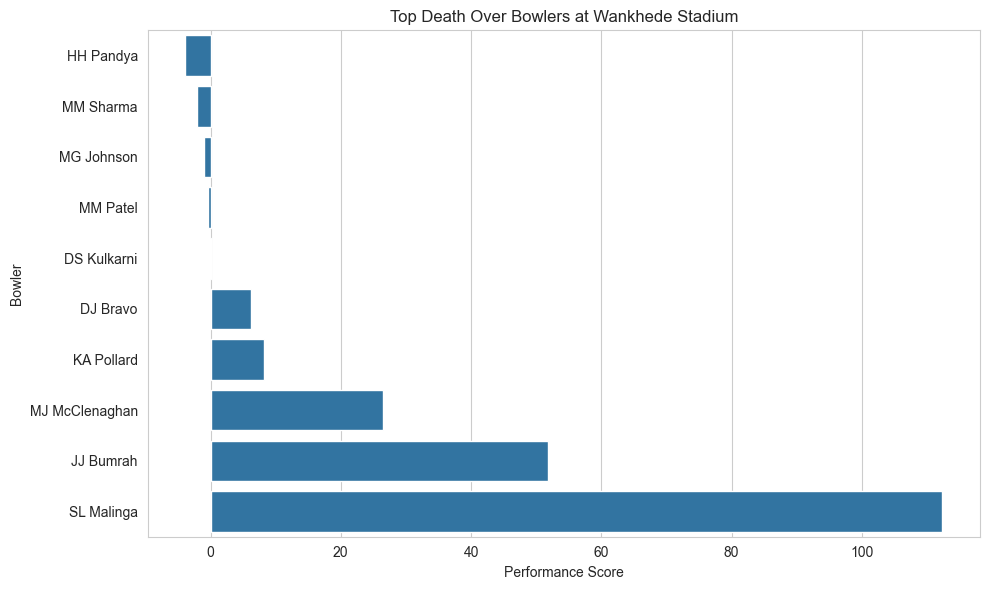

In [104]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_bowlers.sort_values(by='score'),
    x='score',
    y='bowler'
)

plt.title(f"Top Death Over Bowlers at {GROUND}")
plt.xlabel("Performance Score")
plt.ylabel("Bowler")

plt.tight_layout()
plt.show()

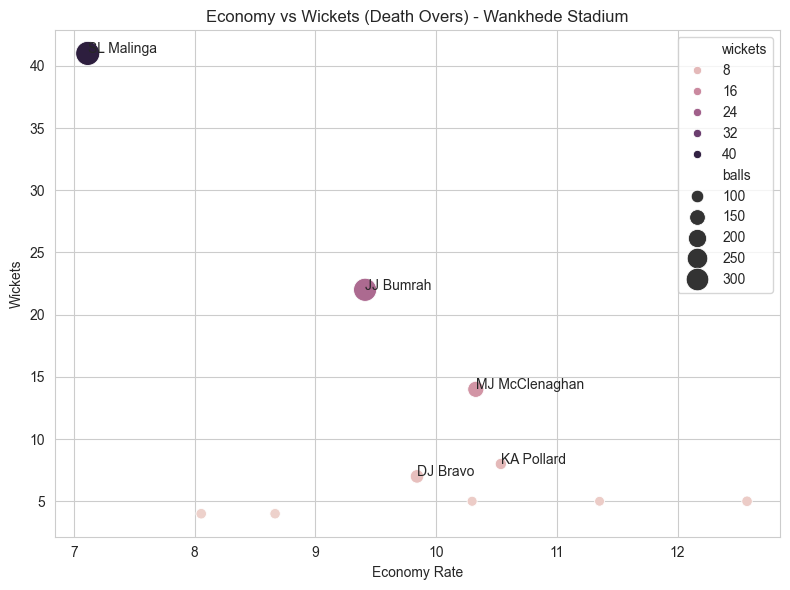

In [105]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=bowler_stats,
    x='economy',
    y='wickets',
    size='balls',
    hue='wickets',
    sizes=(50, 300)
)

plt.title(f"Economy vs Wickets (Death Overs) - {GROUND}")
plt.xlabel("Economy Rate")
plt.ylabel("Wickets")

top5 = bowler_stats.head(5)
for _, row in top5.iterrows():
    plt.text(row['economy'], row['wickets'], row['bowler'])

plt.tight_layout()
plt.show()

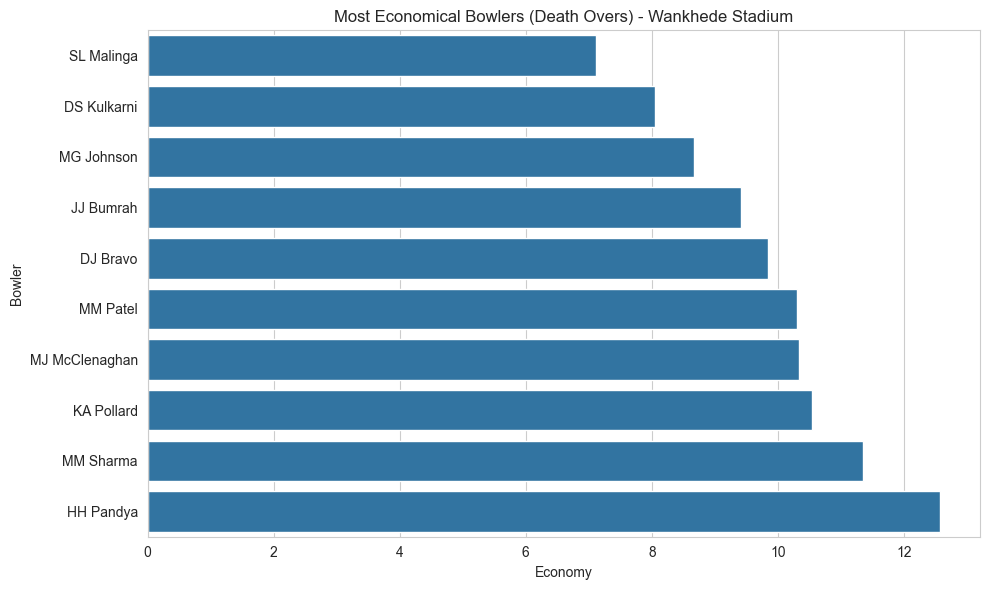

In [106]:
eco = bowler_stats.sort_values(by='economy').head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=eco,
    x='economy',
    y='bowler'
)

plt.title(f"Most Economical Bowlers (Death Overs) - {GROUND}")
plt.xlabel("Economy")
plt.ylabel("Bowler")

plt.tight_layout()
plt.show()

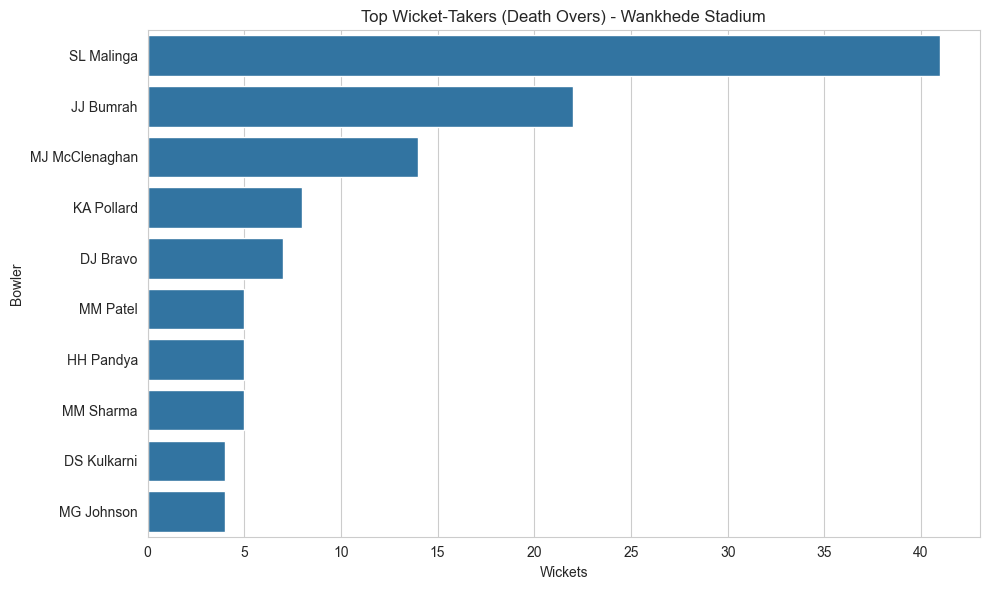

In [107]:
wkts = bowler_stats.sort_values(by='wickets', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=wkts,
    x='wickets',
    y='bowler'
)

plt.title(f"Top Wicket-Takers (Death Overs) - {GROUND}")
plt.xlabel("Wickets")
plt.ylabel("Bowler")

plt.tight_layout()
plt.show()